In [ ]:
import pandas as pd
import numpy as np
import io
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn import metrics
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# EDA

In [ ]:
url = "https://media.githubusercontent.com/media/shirleydhinakar/Wesad_HRV_Dataset/main/wesad-chest-combined-classification-hrv.csv"
read_data = requests.get(url).content
df = pd.read_csv(io.StringIO(read_data.decode('utf-8')))
df.sample(5)

,MEAN_RR,MEDIAN_RR,SDRR,RMSSD,SDSD,SDRR_RMSSD,HR,pNN25,pNN50,SD1,...,MEAN_RR_MEAN_MEAN_REL_RR,SD2_LF,HR_LF,HR_HF,HF_VLF,subject id,condition,SSSQ class,SSSQ Label,condition label
65206,599.628638,595.200040,63.919035,13.972669,13.969796,4.574576,101.132805,6.75,1.0,9.890540,...,-9.605898e+05,0.061111,0.068783,1.223077,0.055693,10,stress,low,0,2
13007,456.879736,442.171440,59.756516,9.143623,9.136488,6.535322,133.500930,0.25,0.0,6.468583,...,5.908681e+05,1.946307,3.083695,4.629022,0.150498,16,stress,low,0,2
89592,710.454681,707.480580,45.488777,8.849869,8.841988,5.140051,84.795624,1.25,0.0,6.260079,...,-1.310170e+06,0.240246,0.318182,4.742475,0.021706,14,amusement,low,0,1
85652,661.785907,658.052565,26.667815,6.085732,6.085693,4.382022,90.808195,0.25,0.0,4.308637,...,1.102269e+08,0.207194,0.502171,6.742627,0.043044,13,baseline,medium,1,0
3040,750.710728,755.711445,109.554692,22.812829,22.810485,4.802328,81.687551,24.50,3.5,16.149699,...,1.551555e+06,0.048356,0.025635,1.681599,0.019944,7,stress,medium,1,2


In [ ]:
# df = df.sample(1000)

In [ ]:
df.shape

(135650, 67)

In [ ]:
df.columns

Index(['MEAN_RR', 'MEDIAN_RR', 'SDRR', 'RMSSD', 'SDSD', 'SDRR_RMSSD', 'HR',
       'pNN25', 'pNN50', 'SD1', 'SD2', 'KURT', 'SKEW', 'MEAN_REL_RR',
       'MEDIAN_REL_RR', 'SDRR_REL_RR', 'RMSSD_REL_RR', 'SDSD_REL_RR',
       'SDRR_RMSSD_REL_RR', 'KURT_REL_RR', 'SKEW_REL_RR', 'VLF', 'VLF_PCT',
       'LF', 'LF_PCT', 'LF_NU', 'HF', 'HF_PCT', 'HF_NU', 'TP', 'LF_HF',
       'HF_LF', 'MEAN_RR_LOG', 'MEAN_RR_SQRT', 'TP_SQRT', 'MEDIAN_REL_RR_LOG',
       'RMSSD_REL_RR_LOG', 'SDSD_REL_RR_LOG', 'VLF_LOG', 'LF_LOG', 'HF_LOG',
       'TP_LOG', 'LF_HF_LOG', 'RMSSD_LOG', 'SDRR_RMSSD_LOG', 'pNN25_LOG',
       'pNN50_LOG', 'SD1_LOG', 'KURT_YEO_JONSON', 'SKEW_YEO_JONSON',
       'MEAN_REL_RR_YEO_JONSON', 'SKEW_REL_RR_YEO_JONSON', 'LF_BOXCOX',
       'HF_BOXCOX', 'SD1_BOXCOX', 'KURT_SQUARE', 'HR_SQRT',
       'MEAN_RR_MEAN_MEAN_REL_RR', 'SD2_LF', 'HR_LF', 'HR_HF', 'HF_VLF',
       'subject id', 'condition', 'SSSQ class', 'SSSQ Label',
       'condition label'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135650 entries, 0 to 135649
Data columns (total 67 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   MEAN_RR                   135650 non-null  float64
 1   MEDIAN_RR                 135650 non-null  float64
 2   SDRR                      135650 non-null  float64
 3   RMSSD                     135650 non-null  float64
 4   SDSD                      135650 non-null  float64
 5   SDRR_RMSSD                135650 non-null  float64
 6   HR                        135650 non-null  float64
 7   pNN25                     135650 non-null  float64
 8   pNN50                     135650 non-null  float64
 9   SD1                       135650 non-null  float64
 10  SD2                       135650 non-null  float64
 11  KURT                      135650 non-null  float64
 12  SKEW                      135650 non-null  float64
 13  MEAN_REL_RR               135650 non-null  f

In [ ]:
df.describe()

,MEAN_RR,MEDIAN_RR,SDRR,RMSSD,SDSD,SDRR_RMSSD,HR,pNN25,pNN50,SD1,...,KURT_SQUARE,HR_SQRT,MEAN_RR_MEAN_MEAN_REL_RR,SD2_LF,HR_LF,HR_HF,HF_VLF,subject id,SSSQ Label,condition label
count,135650.000000,135650.000000,135650.000000,135650.000000,135650.000000,135650.000000,135650.000000,135650.000000,135650.000000,135650.000000,...,1.356500e+05,135650.000000,1.356500e+05,135650.000000,135650.000000,135650.000000,135650.000000,135650.000000,135650.000000,135650.000000
mean,788.515184,786.845673,71.453748,14.379418,14.376136,5.247878,80.203812,10.396622,1.026915,10.178226,...,1.357090e+00,8.904329,-1.761317e+06,0.166589,0.210475,8.309048,0.041303,9.398349,0.875245,0.773727
std,156.334847,160.113990,33.646350,6.134973,6.134411,1.792526,17.913204,10.857041,1.865541,4.343130,...,5.323943e+00,0.957470,1.070482e+09,0.207166,0.469279,14.892431,0.081219,4.709621,0.780052,0.882485
min,411.068840,411.966595,13.786706,2.294390,2.292144,1.887603,48.183943,0.000000,0.000000,1.622825,...,3.871992e-10,6.941465,-3.426834e+11,0.021295,0.008200,0.294702,0.000009,2.000000,0.000000,0.000000
25%,695.450860,689.389645,51.839395,9.579017,9.576334,4.025865,68.227916,2.000000,0.000000,6.779992,...,6.322669e-02,8.260019,-3.607337e+06,0.073939,0.048338,2.251744,0.005567,5.000000,0.000000,0.000000
50%,798.200622,797.564400,65.238376,13.578235,13.576345,5.028439,75.988575,6.500000,0.000000,9.611978,...,2.536286e-01,8.717143,-9.391674e+05,0.111455,0.092320,4.213662,0.014356,9.000000,1.000000,0.000000
75%,888.053029,892.774831,86.848219,18.170919,18.165098,6.001586,86.975168,15.500000,1.250000,12.860790,...,7.131422e-01,9.326048,3.286467e+06,0.184950,0.203164,8.530982,0.042999,14.000000,1.000000,2.000000
max,1341.611513,1181.686350,418.066612,34.881131,34.880732,22.194700,146.191044,46.750000,11.500000,24.695368,...,2.459810e+02,12.090949,1.092115e+11,4.771071,9.714187,537.538316,1.129262,17.000000,2.000000,2.000000


In [ ]:
df.isnull().sum()

MEAN_RR            0
MEDIAN_RR          0
SDRR               0
RMSSD              0
SDSD               0
                  ..
subject id         0
condition          0
SSSQ class         0
SSSQ Label         0
condition label    0
Length: 67, dtype: int64

In [ ]:
df.isnull().sum().sum()

0

In [ ]:
df.isna().sum()

MEAN_RR            0
MEDIAN_RR          0
SDRR               0
RMSSD              0
SDSD               0
                  ..
subject id         0
condition          0
SSSQ class         0
SSSQ Label         0
condition label    0
Length: 67, dtype: int64

In [ ]:
df.isna().sum().sum()

0

In [ ]:
def null_percentage(column):
    df_name = column.name
    nans = np.count_nonzero(column.isnull().values)
    total = column.size
    frac = nans / total
    perc = int(frac * 100)
    print('%d%% or %d missing values from [ %s ] column.' % (perc, nans, df_name))

def check_nan(df):
    columns = df.columns
    for col in columns:
      null_percentage(df[col])

In [ ]:
check_nan(df)

0% or 0 missing values from [ MEAN_RR ] column.
0% or 0 missing values from [ MEDIAN_RR ] column.
0% or 0 missing values from [ SDRR ] column.
0% or 0 missing values from [ RMSSD ] column.
0% or 0 missing values from [ SDSD ] column.
0% or 0 missing values from [ SDRR_RMSSD ] column.
0% or 0 missing values from [ HR ] column.
0% or 0 missing values from [ pNN25 ] column.
0% or 0 missing values from [ pNN50 ] column.
0% or 0 missing values from [ SD1 ] column.
0% or 0 missing values from [ SD2 ] column.
0% or 0 missing values from [ KURT ] column.
0% or 0 missing values from [ SKEW ] column.
0% or 0 missing values from [ MEAN_REL_RR ] column.
0% or 0 missing values from [ MEDIAN_REL_RR ] column.
0% or 0 missing values from [ SDRR_REL_RR ] column.
0% or 0 missing values from [ RMSSD_REL_RR ] column.
0% or 0 missing values from [ SDSD_REL_RR ] column.
0% or 0 missing values from [ SDRR_RMSSD_REL_RR ] column.
0% or 0 missing values from [ KURT_REL_RR ] column.
0% or 0 missing values from [

In [ ]:
 num_df = df._get_numeric_data()
obj_df = df.select_dtypes(include=['object'])
print(num_df.shape, obj_df.shape, df.shape)

(135650, 65) (135650, 2) (135650, 67)


# DATA IMABALANCE

In [ ]:
df[['condition label','condition']].value_counts()

condition label  condition
0                baseline     71640
2                stress       40946
1                amusement    23064
dtype: int64

<Axes: xlabel='condition label', ylabel='Count'>

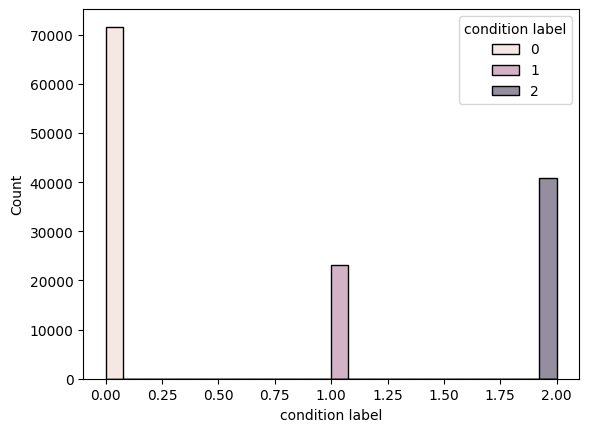

In [ ]:
sns.histplot(x = df["condition label"], data = df["condition label"], hue= df["condition label"])

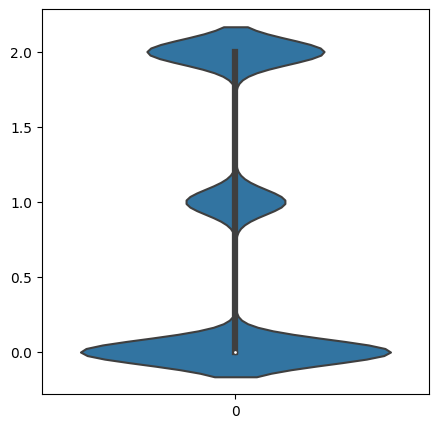

In [ ]:
plt.figure(figsize=(5, 5))
sns.violinplot(df["condition label"])
plt.show()

# CORRELATION

In [ ]:
corr = num_df.corr()

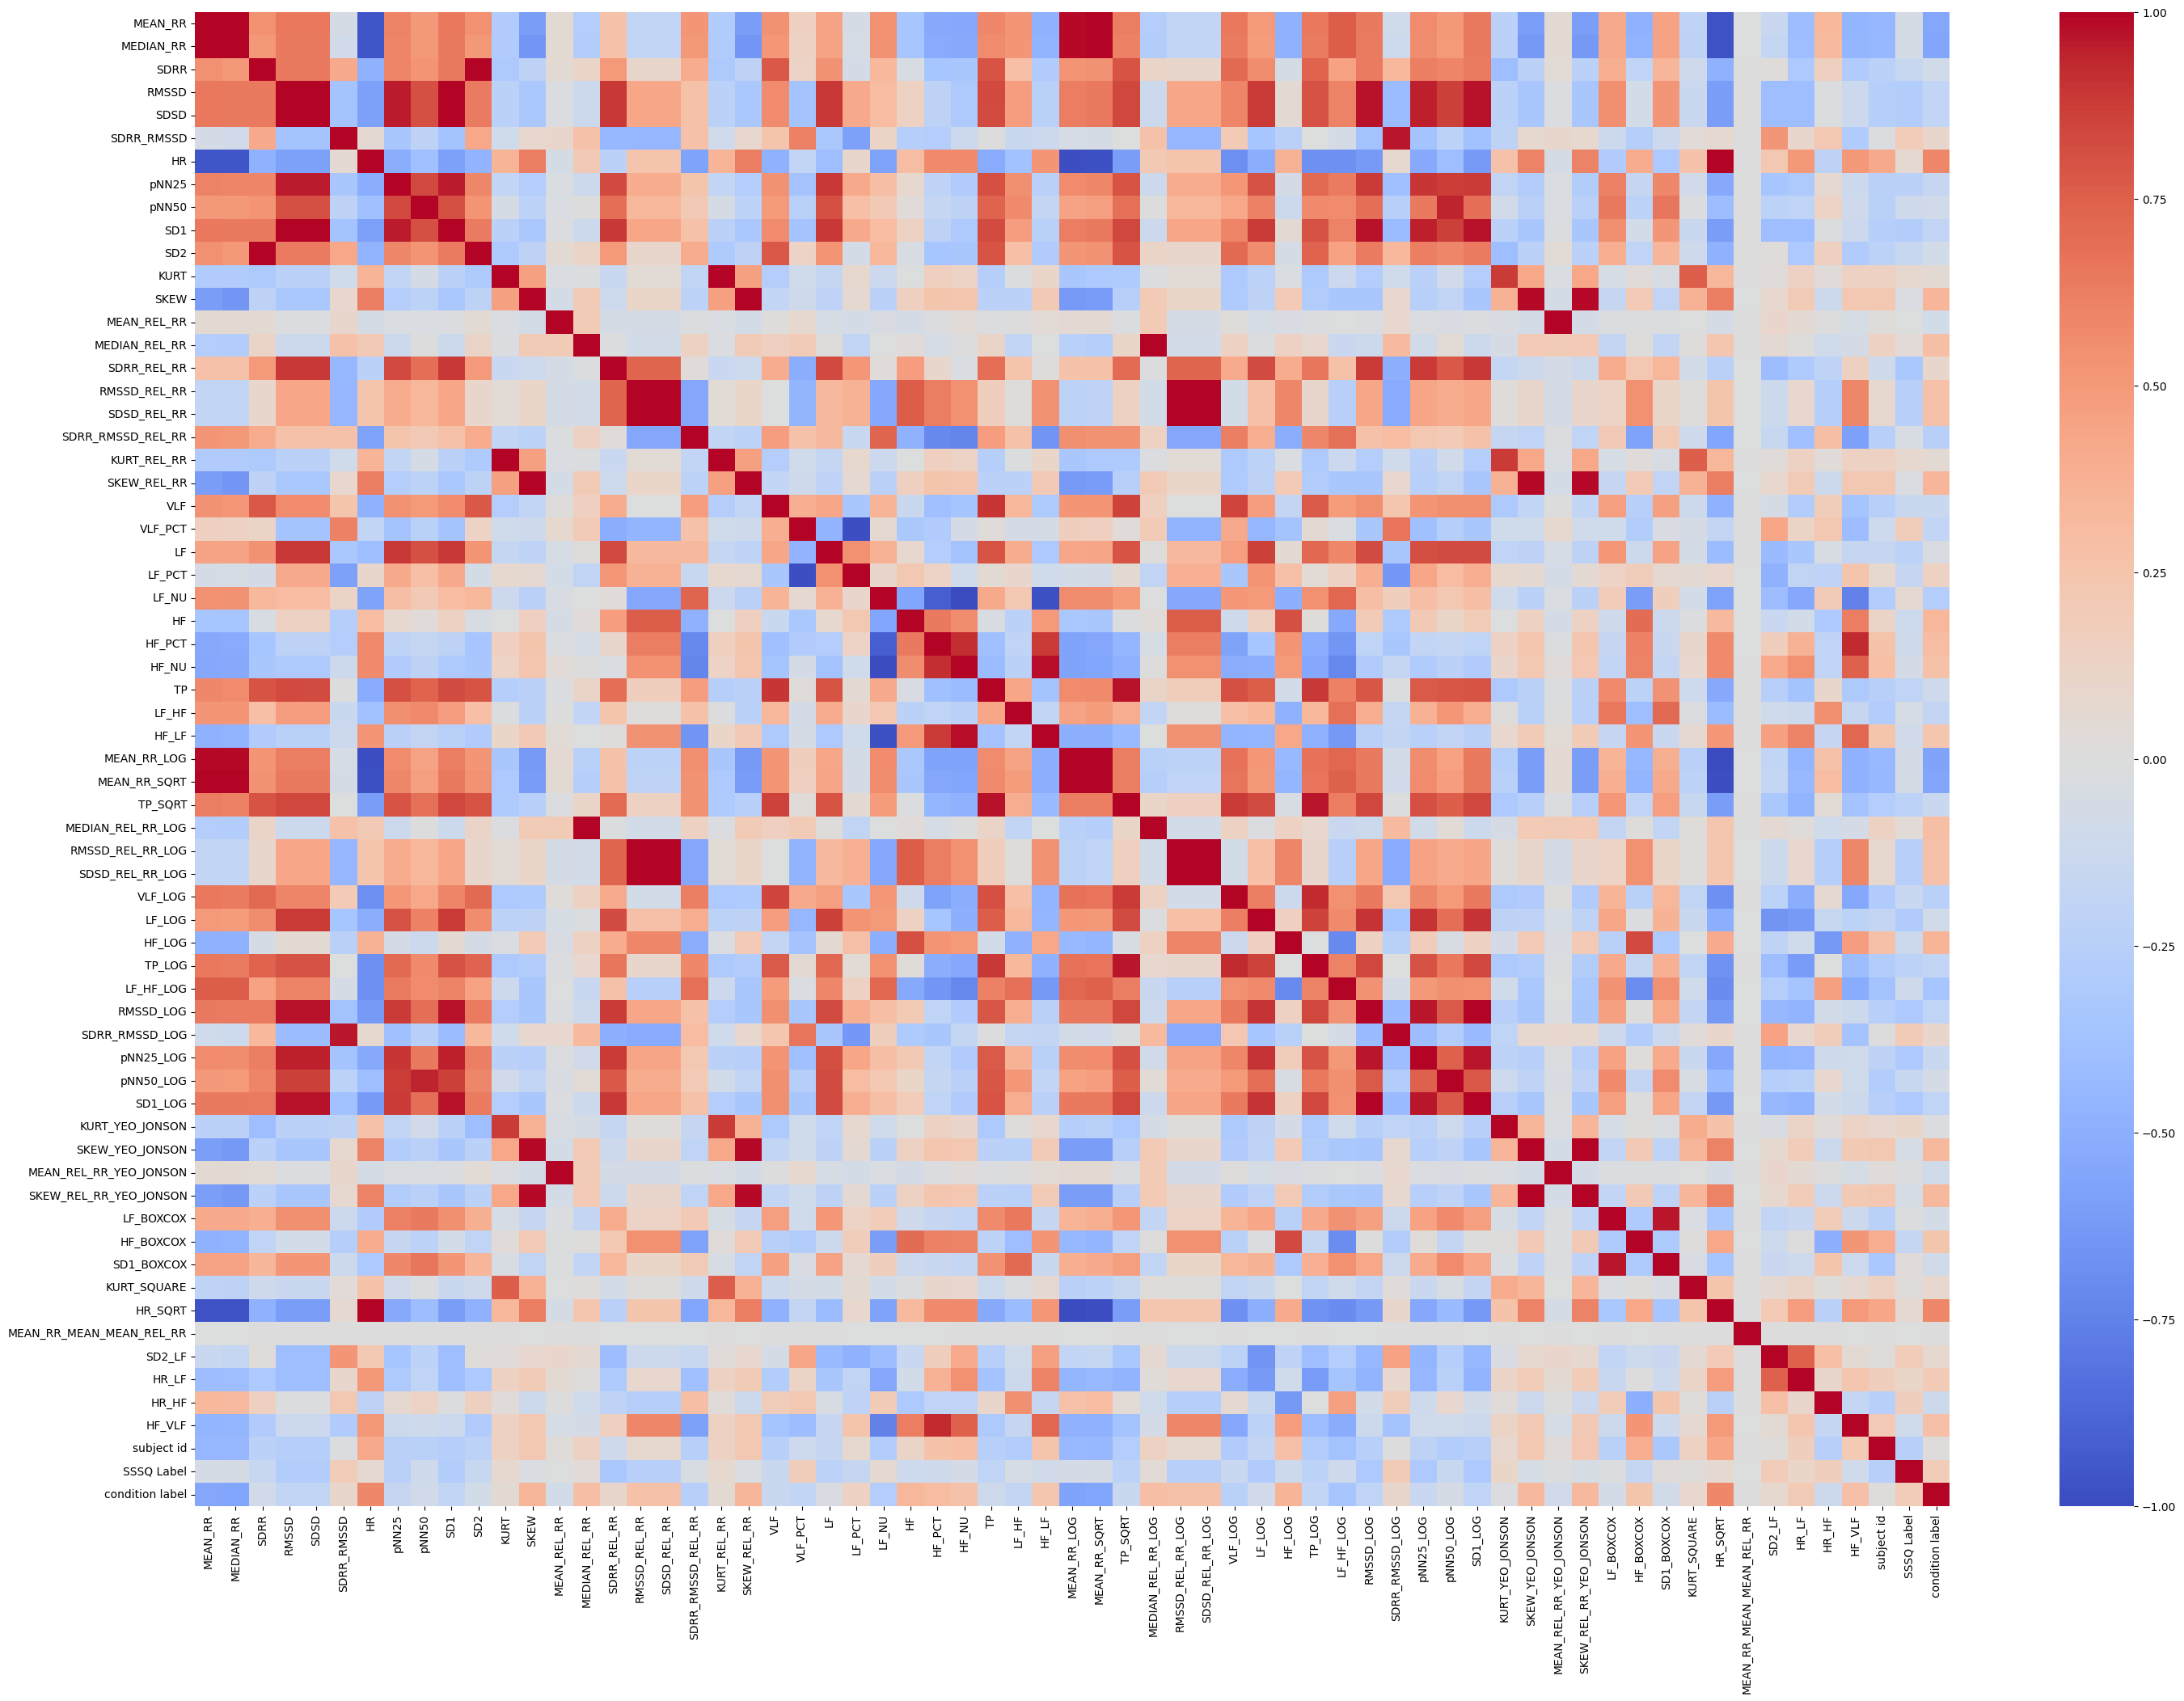

In [ ]:
plt.figure(figsize=(35, 24))
sns.heatmap(corr, cmap = "coolwarm")
plt.show()

In [ ]:
filteredCorr = corr[((corr >= .75) | (corr <= -.75)) & (corr !=1.000)]
filteredCorr.unstack().sort_values().drop_duplicates()

LF_NU              HF_NU             -1.000000
MEAN_RR_LOG        HR_SQRT           -0.996757
                   HR                -0.989702
HR_SQRT            MEAN_RR_SQRT      -0.989128
VLF_PCT            LF_PCT            -0.985322
                                        ...   
MEDIAN_REL_RR_LOG  MEDIAN_REL_RR      0.999999
RMSSD_REL_RR_LOG   SDSD_REL_RR_LOG    1.000000
RMSSD_REL_RR       SDSD_REL_RR        1.000000
SDSD               SD1                1.000000
MEAN_RR            MEAN_RR                 NaN
Length: 148, dtype: float64

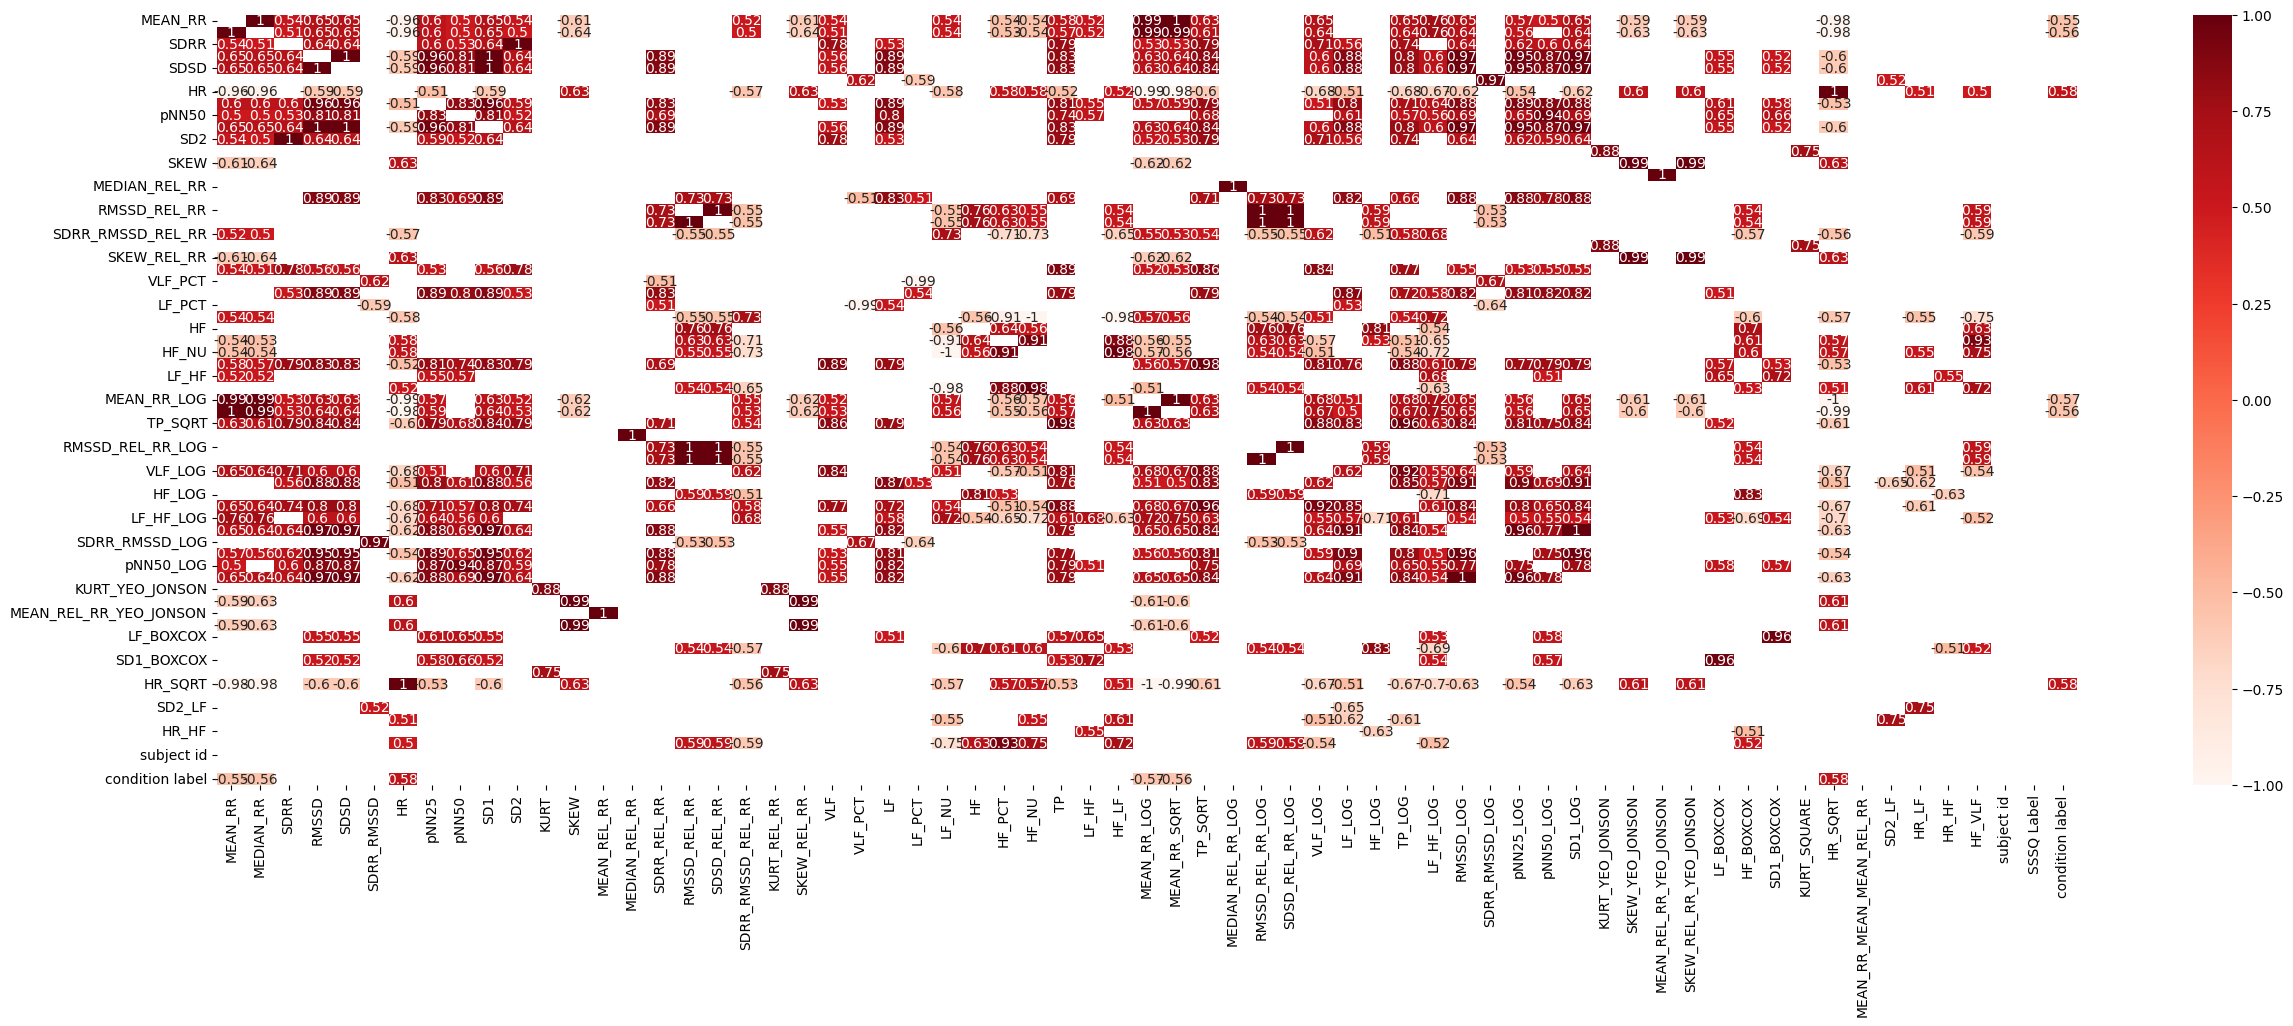

In [ ]:
filteredDf = corr[((corr >= .5) | (corr <= -.5)) & (corr !=1.000)]
plt.figure(figsize=(30,10))
sns.heatmap(filteredDf, annot=True, cmap="Reds")
plt.show()

In [ ]:
filteredDf.shape, filteredCorr.shape

((65, 65), (65, 65))

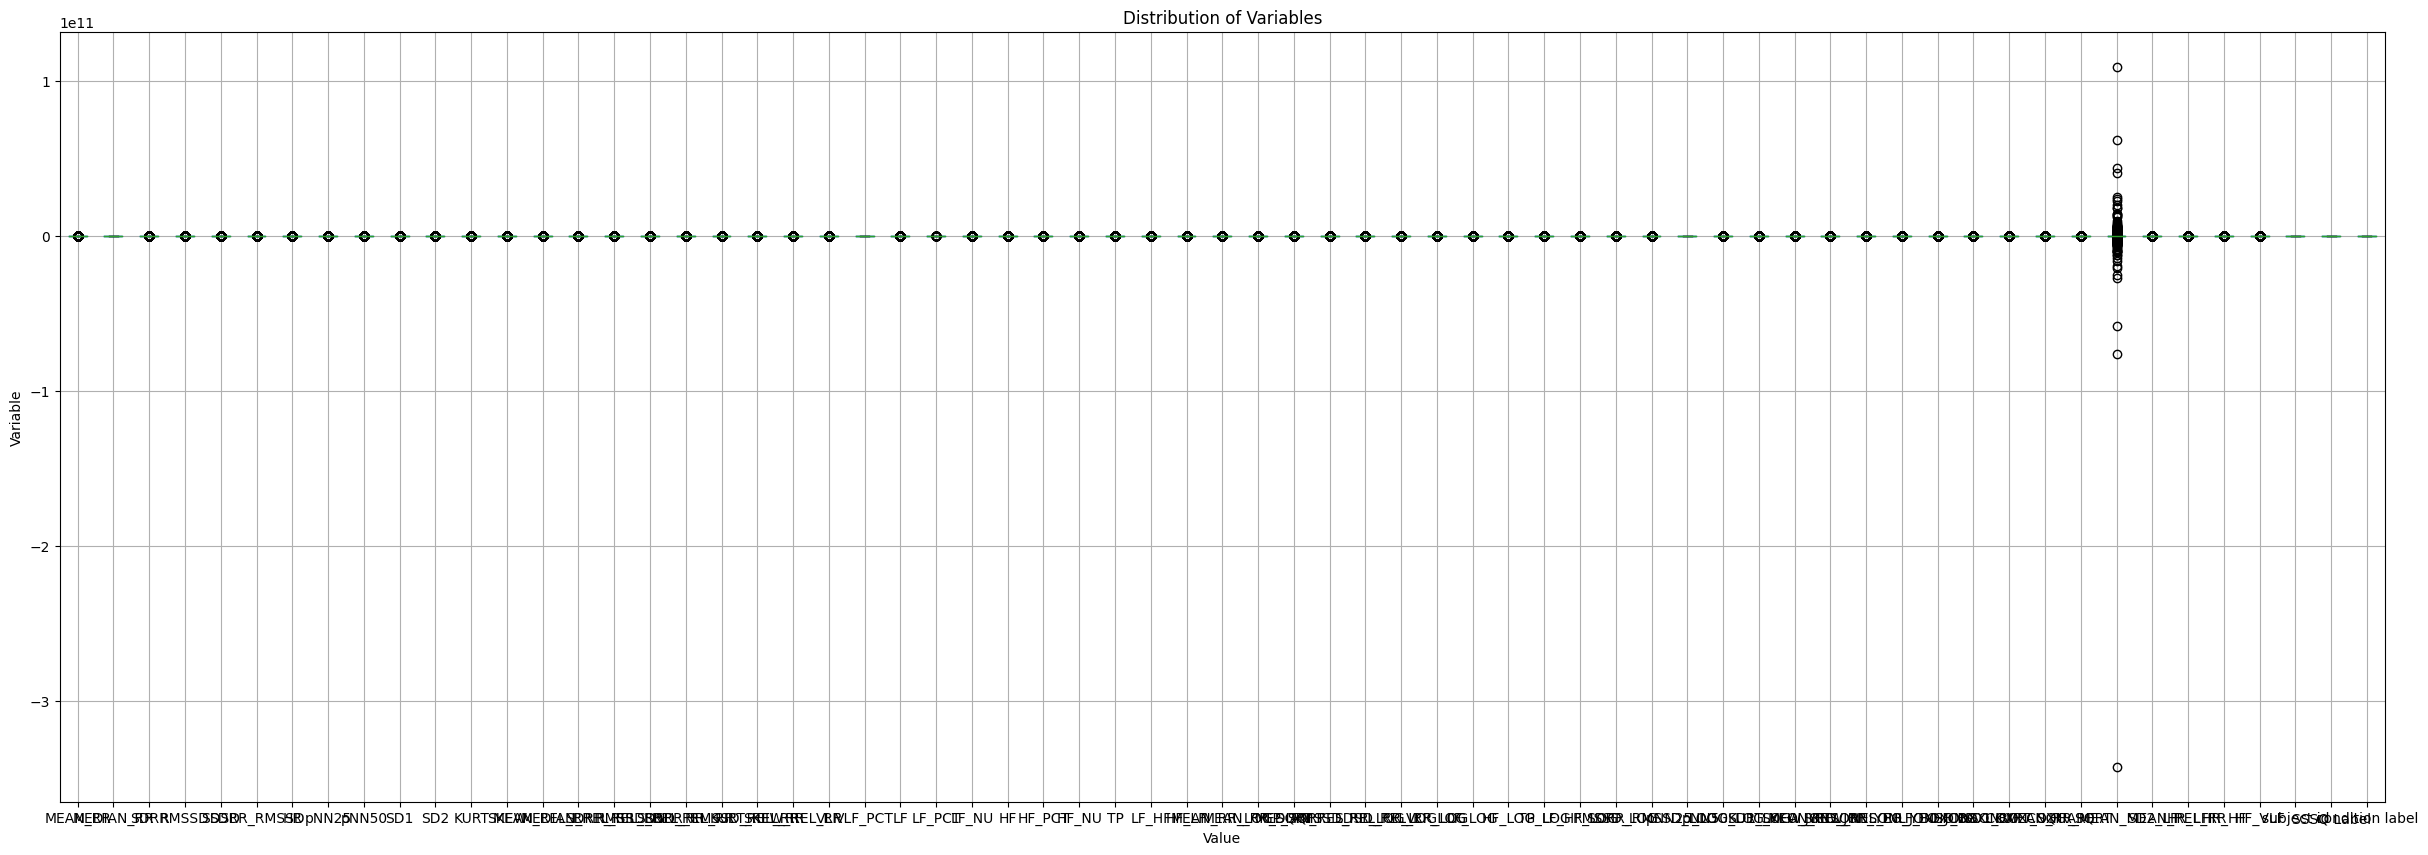

In [ ]:
plt.figure(figsize=(30, 10))
num_df.boxplot()
plt.xlabel('Value')
plt.ylabel('Variable')
plt.title('Distribution of Variables')
plt.grid(alpha=1)
plt.show()

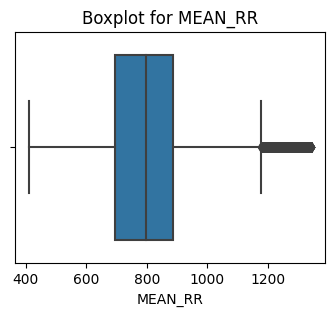

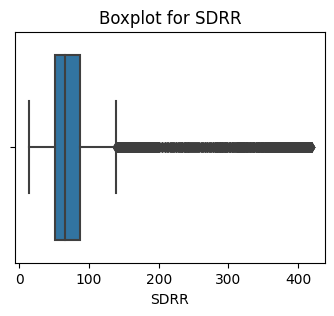

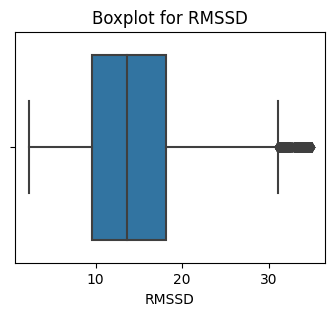

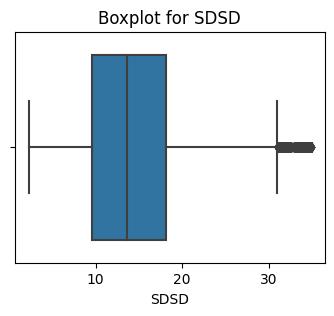

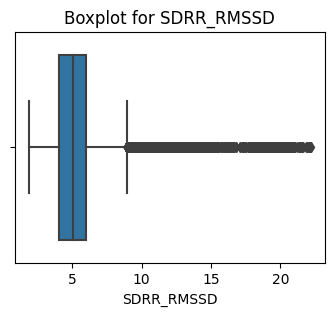

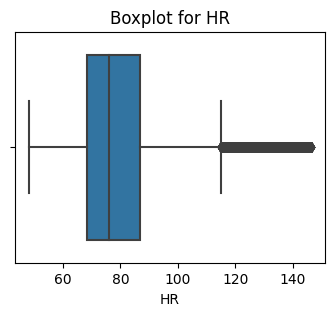

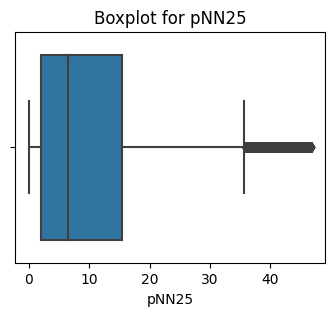

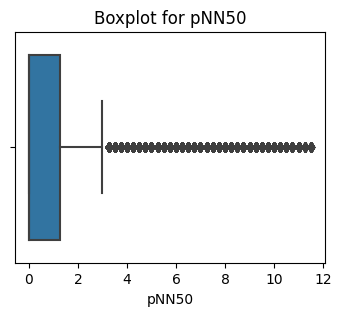

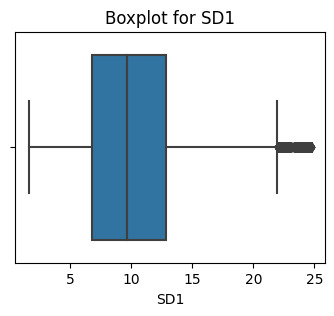

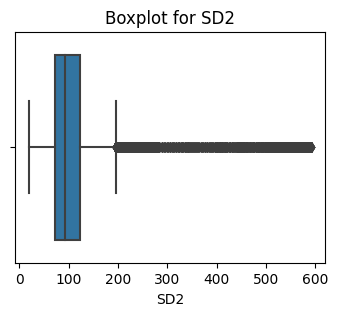

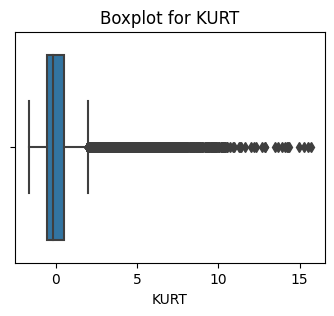

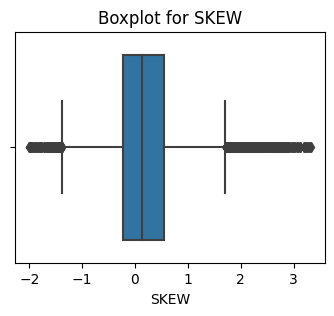

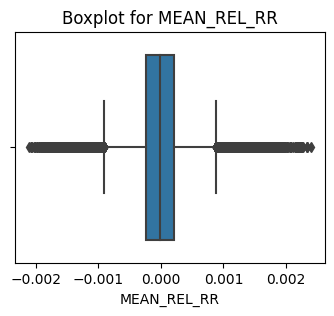

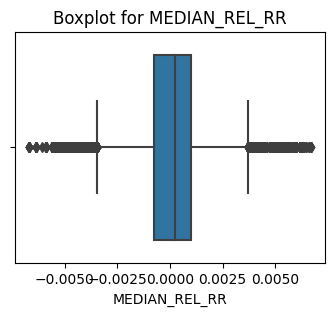

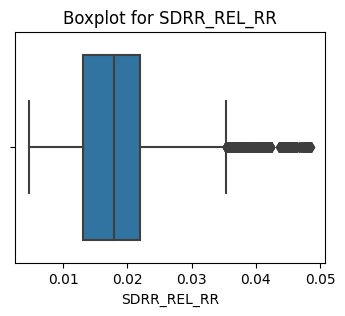

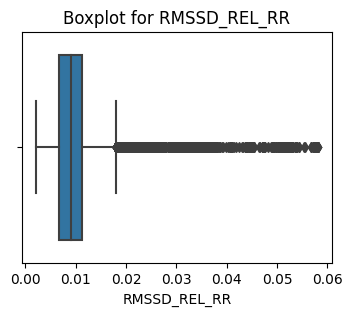

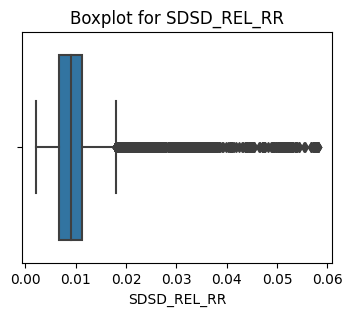

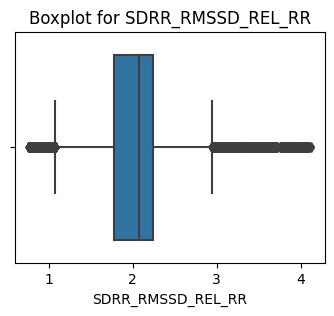

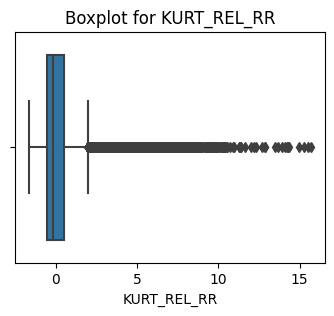

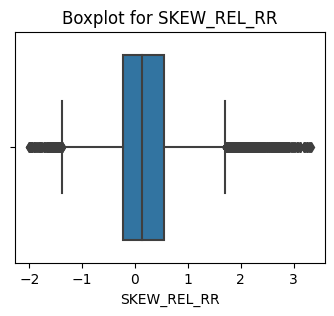

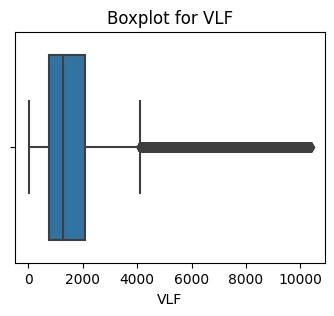

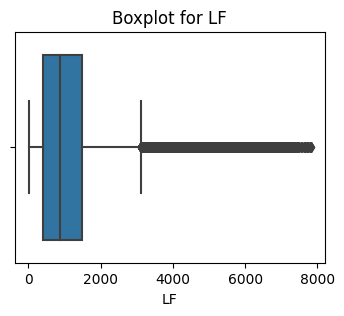

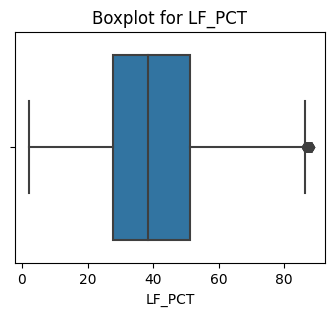

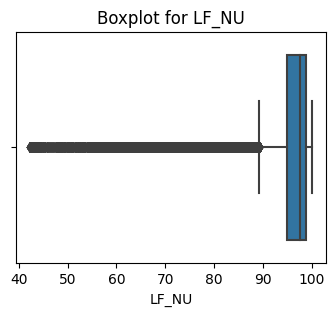

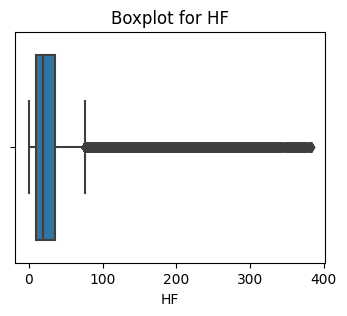

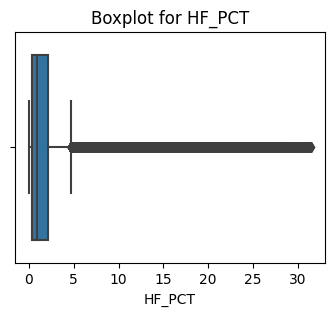

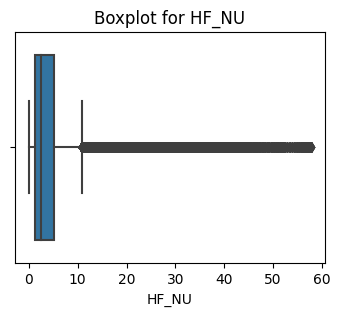

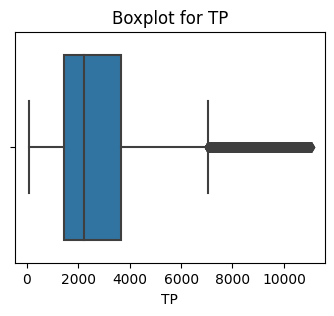

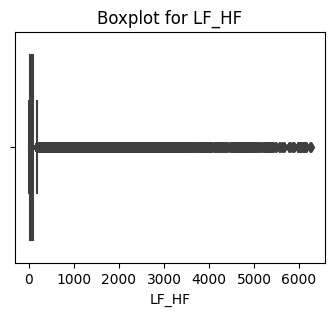

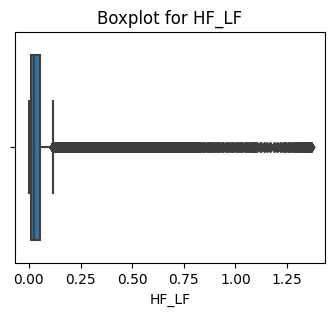

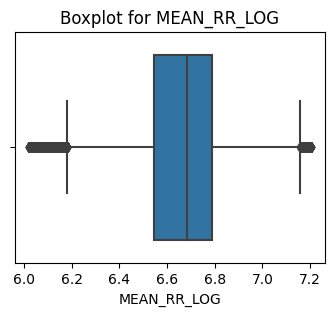

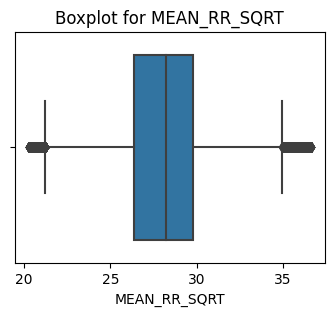

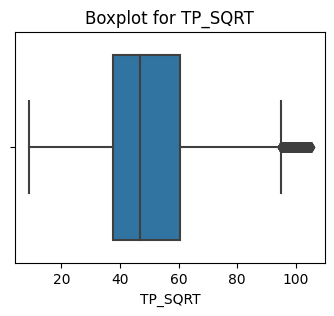

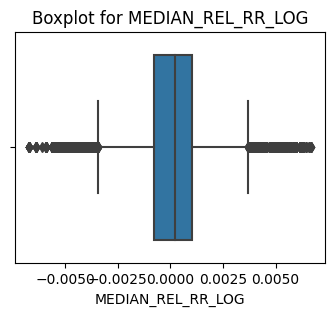

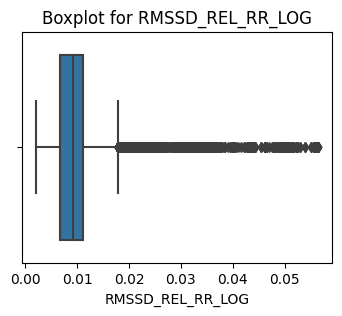

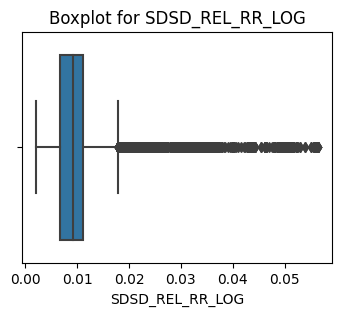

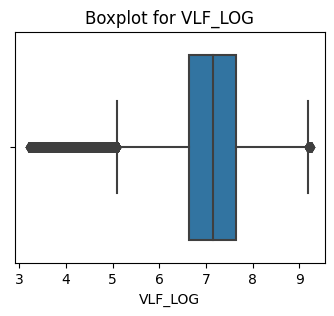

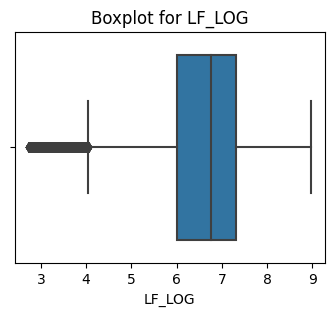

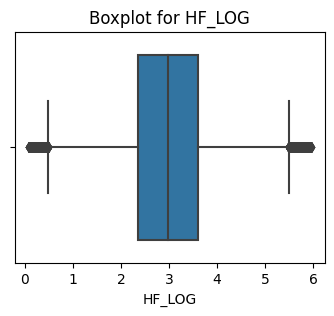

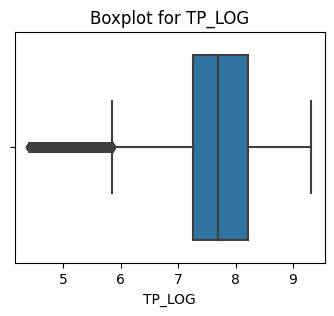

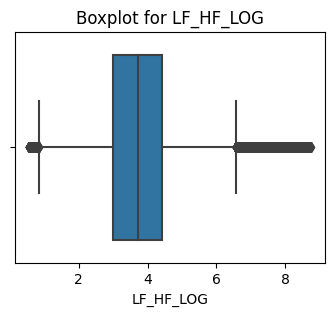

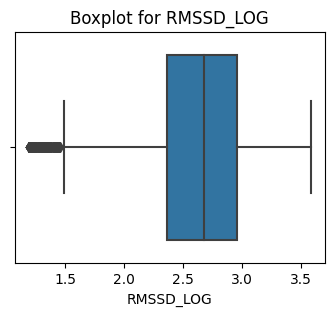

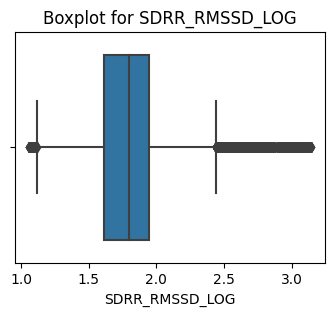

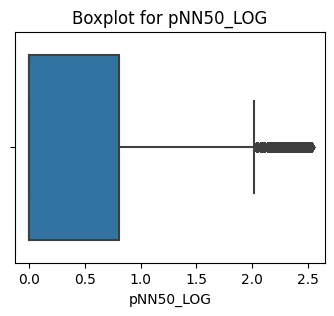

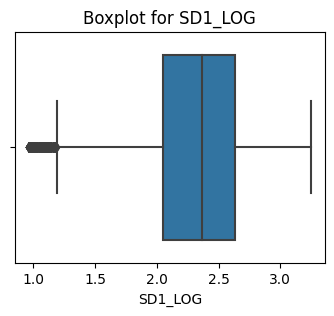

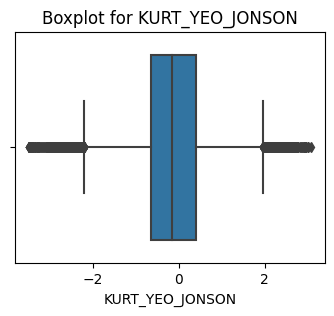

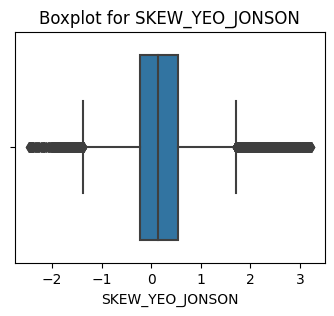

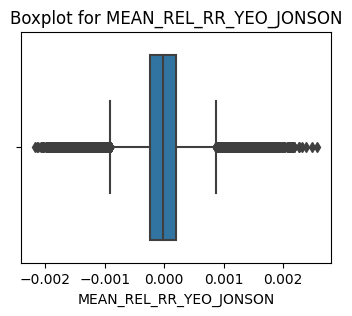

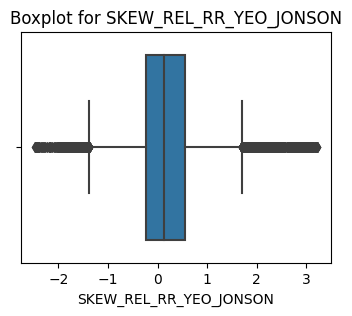

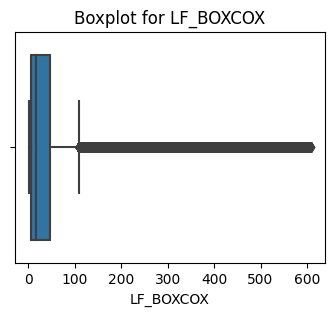

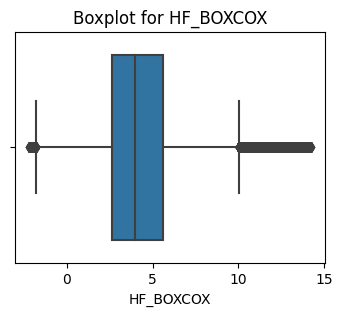

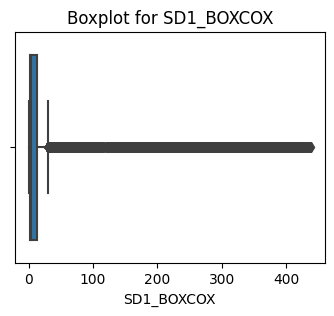

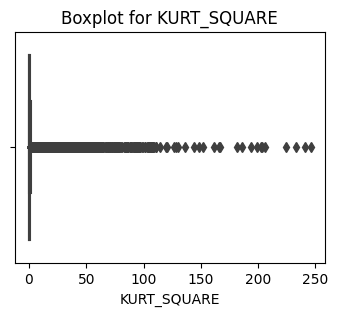

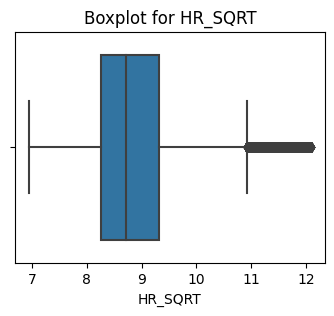

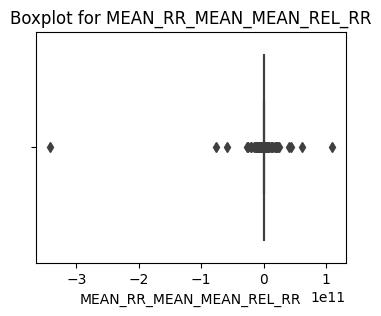

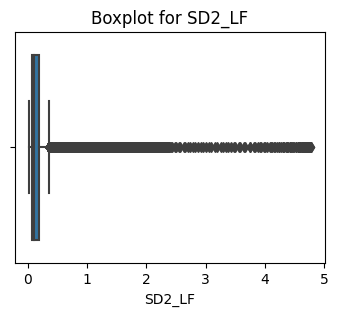

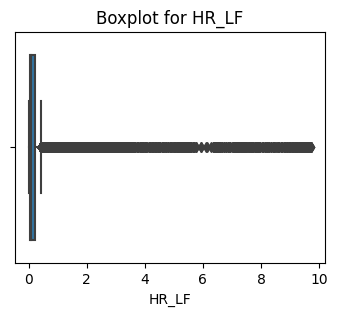

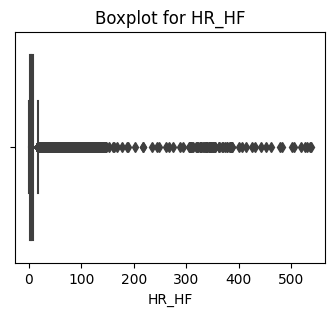

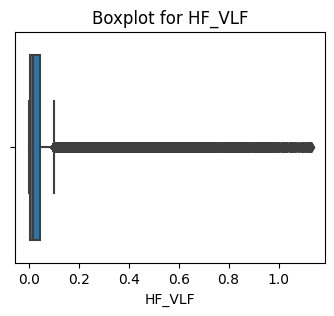

In [ ]:
Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((num_df < (Q1 - 1.5 * IQR)) | (num_df > (Q3 + 1.5 * IQR)))

# Filter columns with outliers
columns_with_outliers = outliers.any()

# Create boxplots for columns with outliers using Seaborn
for column in columns_with_outliers.index:
    if columns_with_outliers[column]:
        plt.figure(figsize=(4, 3))
        sns.boxplot(data=df, x=column)
        plt.title(f'Boxplot for {column}')
        plt.show()

In [ ]:
num_df.shape

(135650, 65)

In [ ]:
num_df.columns

Index(['MEAN_RR', 'MEDIAN_RR', 'SDRR', 'RMSSD', 'SDSD', 'SDRR_RMSSD', 'HR',
       'pNN25', 'pNN50', 'SD1', 'SD2', 'KURT', 'SKEW', 'MEAN_REL_RR',
       'MEDIAN_REL_RR', 'SDRR_REL_RR', 'RMSSD_REL_RR', 'SDSD_REL_RR',
       'SDRR_RMSSD_REL_RR', 'KURT_REL_RR', 'SKEW_REL_RR', 'VLF', 'VLF_PCT',
       'LF', 'LF_PCT', 'LF_NU', 'HF', 'HF_PCT', 'HF_NU', 'TP', 'LF_HF',
       'HF_LF', 'MEAN_RR_LOG', 'MEAN_RR_SQRT', 'TP_SQRT', 'MEDIAN_REL_RR_LOG',
       'RMSSD_REL_RR_LOG', 'SDSD_REL_RR_LOG', 'VLF_LOG', 'LF_LOG', 'HF_LOG',
       'TP_LOG', 'LF_HF_LOG', 'RMSSD_LOG', 'SDRR_RMSSD_LOG', 'pNN25_LOG',
       'pNN50_LOG', 'SD1_LOG', 'KURT_YEO_JONSON', 'SKEW_YEO_JONSON',
       'MEAN_REL_RR_YEO_JONSON', 'SKEW_REL_RR_YEO_JONSON', 'LF_BOXCOX',
       'HF_BOXCOX', 'SD1_BOXCOX', 'KURT_SQUARE', 'HR_SQRT',
       'MEAN_RR_MEAN_MEAN_REL_RR', 'SD2_LF', 'HR_LF', 'HR_HF', 'HF_VLF',
       'subject id', 'SSSQ Label', 'condition label'],
      dtype='object')

In [ ]:
extractedDf = num_df.drop(num_df[num_df['condition label'] == 1].index)
extractedDf.reset_index(inplace = True)

In [ ]:
extractedDf.shape

(112586, 66)

In [ ]:
extractedDf.columns

Index(['index', 'MEAN_RR', 'MEDIAN_RR', 'SDRR', 'RMSSD', 'SDSD', 'SDRR_RMSSD',
       'HR', 'pNN25', 'pNN50', 'SD1', 'SD2', 'KURT', 'SKEW', 'MEAN_REL_RR',
       'MEDIAN_REL_RR', 'SDRR_REL_RR', 'RMSSD_REL_RR', 'SDSD_REL_RR',
       'SDRR_RMSSD_REL_RR', 'KURT_REL_RR', 'SKEW_REL_RR', 'VLF', 'VLF_PCT',
       'LF', 'LF_PCT', 'LF_NU', 'HF', 'HF_PCT', 'HF_NU', 'TP', 'LF_HF',
       'HF_LF', 'MEAN_RR_LOG', 'MEAN_RR_SQRT', 'TP_SQRT', 'MEDIAN_REL_RR_LOG',
       'RMSSD_REL_RR_LOG', 'SDSD_REL_RR_LOG', 'VLF_LOG', 'LF_LOG', 'HF_LOG',
       'TP_LOG', 'LF_HF_LOG', 'RMSSD_LOG', 'SDRR_RMSSD_LOG', 'pNN25_LOG',
       'pNN50_LOG', 'SD1_LOG', 'KURT_YEO_JONSON', 'SKEW_YEO_JONSON',
       'MEAN_REL_RR_YEO_JONSON', 'SKEW_REL_RR_YEO_JONSON', 'LF_BOXCOX',
       'HF_BOXCOX', 'SD1_BOXCOX', 'KURT_SQUARE', 'HR_SQRT',
       'MEAN_RR_MEAN_MEAN_REL_RR', 'SD2_LF', 'HR_LF', 'HR_HF', 'HF_VLF',
       'subject id', 'SSSQ Label', 'condition label'],
      dtype='object')

In [ ]:
extractedDf[['condition label']].value_counts()

condition label
0                  71640
2                  40946
dtype: int64

In [ ]:
extractedDf['condition label'] = extractedDf['condition label'].replace(2, 1)

In [ ]:
extractedDf[['condition label']].value_counts()

condition label
0                  71640
1                  40946
dtype: int64

In [ ]:
max_class = extractedDf[extractedDf['condition label']== 0]
min_class = extractedDf[extractedDf['condition label']== 1]
print(max_class.shape, min_class.shape)

(71640, 66) (40946, 66)


In [ ]:
# Downsampling
from sklearn.utils import resample
max_class_downsampled = resample(max_class, replace=True, n_samples=len(min_class), random_state=42)

In [ ]:
finalDf = pd.concat([max_class_downsampled, min_class])

In [ ]:
finalDf[['condition label']].value_counts()

condition label
0                  40946
1                  40946
dtype: int64

In [ ]:
X = finalDf.drop(['index','subject id','condition label'], axis=1)
y = finalDf['condition label']

In [ ]:
X.shape, y.shape

((81892, 63), (81892,))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [ ]:
# https://www.kaggle.com/code/vaseline555/1d-cnn-for-numerical-features

### 1D CNN

In [ ]:
no_of_feat = len(X.columns)
no_of_feat

63

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(np.array(X), y , random_state=104, test_size=0.25, shuffle=True)

X_train = X_train.reshape(-1, no_of_feat, 1)
X_test = X_test.reshape(-1, no_of_feat, 1)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(61419, 63, 1) (20473, 63, 1) (61419,) (20473,)


In [ ]:
X.shape, y.shape

((81892, 63), (81892,))

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Create a 1D CNN model for binary classification
model = Sequential()

# Add 1D convolutional layers
model.add(Conv1D(name = "Conv1", filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(name = "MaxPool1", pool_size=2))
model.add(Conv1D(name = "Conv2", filters=128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(name = "MaxPool2", pool_size=2))
model.add(Conv1D(name = "Conv3", filters=256, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(name = "MaxPool3", pool_size=2))
model.add(Conv1D(name = "Conv4", filters=128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(name = "MaxPool4", pool_size=2))


# Flatten the output for fully connected layers
model.add(Flatten(name = "Flatten"))

# Add dense layers
model.add(Dense(32, activation='relu', name = "Dense1"))
model.add(Dense(1, activation='sigmoid', name = "Output"))  # Output layer with sigmoid activation for binary classification

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

# Print model summary
model.summary()

In [ ]:
# del model
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Create a 1D CNN model for binary classification
model = Sequential()

# Add 1D convolutional layers
model.add(Conv1D(name = "Conv1", filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(name = "MaxPool1", pool_size=2))
model.add(Conv1D(name = "Conv2", filters=128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(name = "MaxPool2", pool_size=2))
model.add(Conv1D(name = "Conv3", filters=256, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(name = "MaxPool3", pool_size=2))
model.add(Conv1D(name = "Conv4", filters=128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(name = "MaxPool4", pool_size=2))


# Flatten the output for fully connected layers
model.add(Flatten(name = "Flatten"))

# Add dense layers
model.add(Dense(32, activation='relu', name = "Dense1"))
model.add(Dense(1, activation='sigmoid', name = "Output"))  # Output layer with sigmoid activation for binary classification

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

# Print model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Conv1 (Conv1D)              (None, 61, 64)            256       
                                                                 
 MaxPool1 (MaxPooling1D)     (None, 30, 64)            0         
                                                                 
 Conv2 (Conv1D)              (None, 28, 128)           24704     
                                                                 
 MaxPool2 (MaxPooling1D)     (None, 14, 128)           0         
                                                                 
 Conv3 (Conv1D)              (None, 12, 256)           98560     
                                                                 
 MaxPool3 (MaxPooling1D)     (None, 6, 256)            0         
                                                                 
 Conv4 (Conv1D)              (None, 4, 128)            9

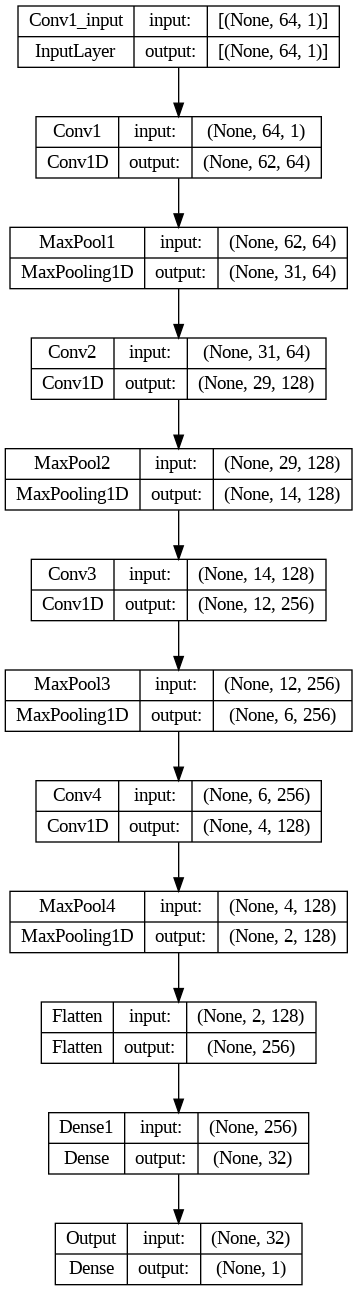

In [ ]:
tf.keras.utils.plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
# Train the model with your dataset
history = model.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.1, verbose=1)

Epoch 1/30
864/864 [==============================] - 18s 20ms/step - loss: 15450.7998 - acc: 0.5128 - val_loss: 107.3036 - val_acc: 0.6001
Epoch 2/30
864/864 [==============================] - 17s 20ms/step - loss: 4800.6558 - acc: 0.6360 - val_loss: 626.4164 - val_acc: 0.6185
Epoch 3/30
864/864 [==============================] - 18s 20ms/step - loss: 5852.3765 - acc: 0.7319 - val_loss: 2325.8589 - val_acc: 0.7996
Epoch 4/30
864/864 [==============================] - 18s 21ms/step - loss: 486.5615 - acc: 0.8033 - val_loss: 12.4775 - val_acc: 0.8851
Epoch 5/30
306/864 [=========>....................] - ETA: 11s - loss: 11.9241 - acc: 0.8440

KeyboardInterrupt: 

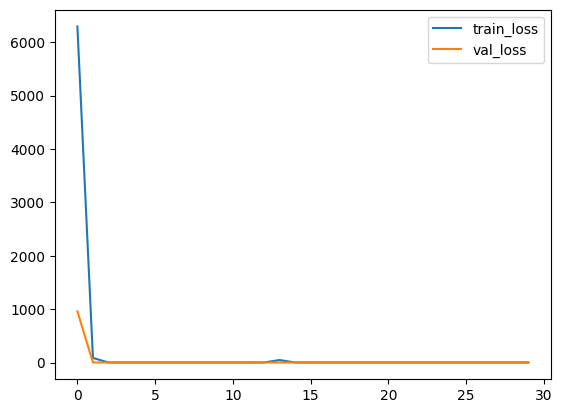

In [ ]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(loc='upper right')
plt.show()

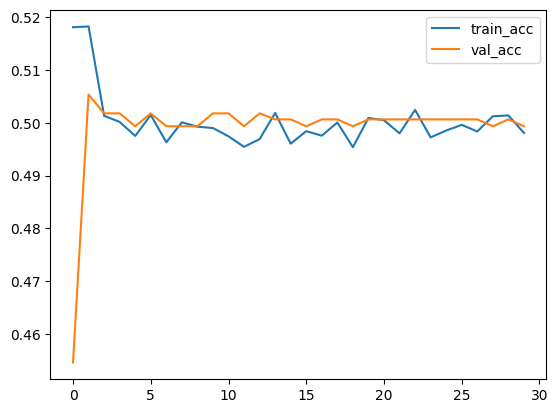

In [ ]:
plt.plot(history.history['acc'], label='train_acc')
plt.plot(history.history['val_acc'], label='val_acc')
plt.legend(loc='upper right')
plt.show()

In [ ]:
result = model.evaluate(X_test, y_test)
print('Accuracy:', result[1])

640/640 [==============================] - 5s 8ms/step - loss: 0.6932 - acc: 0.4983
Accuracy: 0.49831485748291016


In [ ]:
y_pred = model.predict(X_test)

640/640 [==============================] - 5s 8ms/step


In [ ]:
y_pred

array([[0.49643293],
       [0.49643293],
       [0.49643293],
       ...,
       [0.49643293],
       [0.49643293],
       [0.49643293]], dtype=float32)

In [ ]:
y_test

29778    0
60701    0
90806    1
71555    1
38341    1
        ..
17378    1
81597    0
661      1
46957    0
38721    0
Name: condition label, Length: 20473, dtype: int64

In [ ]:
cm = tf.math.confusion_matrix(y_test,y_pred)

<Axes: >

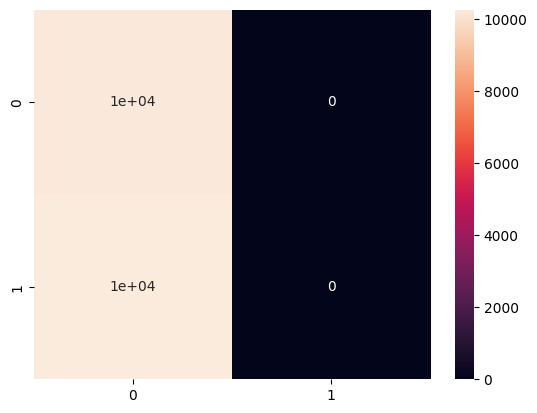

In [ ]:
sns.heatmap(cm, annot = True)

In [ ]:
print(cm)

tf.Tensor(
[[10202     0]
 [10271     0]], shape=(2, 2), dtype=int32)


In [ ]:
precision = cm[1][1]/(cm[1][1]+cm[1][0])
recall = cm[1][1]/(cm[1][1]+cm[0][1])
f1 = (2*precision*recall)/(recall+precision)
print(precision, recall, f1)

tf.Tensor(0.0, shape=(), dtype=float64) tf.Tensor(nan, shape=(), dtype=float64) tf.Tensor(nan, shape=(), dtype=float64)


In [ ]:
49.83